**Diabetes Risk Classifier**

Step 1 — Upload the file:

In [1]:
from google.colab import files
uploaded = files.upload()  # choose Data-diabetes.csv

Saving Data-diabetes.csv to Data-diabetes.csv


Step 2 — Load and peek at the data:


In [2]:
import pandas as pd
import numpy as np

df = pd.read_csv('Data-diabetes.csv')
print(df.shape)
print(df.head())
print(df['Outcome'].value_counts())

(768, 9)
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  
Outcome
0    500
1    268
Name: count, dtype: int64


Step 3 — Clean the data
Some columns have 0 where that's medically impossible (nobody has a blood pressure of 0). Those are hidden missing values, so we replace them with the median.

In [3]:
X = df.drop('Outcome', axis=1)
y = df['Outcome']

cols_with_bad_zeros = ['Glucose','BloodPressure','SkinThickness','Insulin','BMI']
for c in cols_with_bad_zeros:
    X[c] = X[c].replace(0, np.nan)
    X[c] = X[c].fillna(X[c].median())

Step 4 — Split and scale

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

Step 5 — Train three models:

In [5]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier

log = LogisticRegression(max_iter=1000).fit(X_train_s, y_train)
svm = SVC(probability=True, kernel='rbf', random_state=42).fit(X_train_s, y_train)
mlp = MLPClassifier(hidden_layer_sizes=(16,8), max_iter=2000, random_state=42).fit(X_train_s, y_train)

models = {'Logistic Regression': log, 'SVM': svm, 'Neural Network': mlp}

Step 6 — Evaluate each one:

In [6]:
from sklearn.metrics import confusion_matrix, roc_auc_score, precision_score, recall_score, accuracy_score, f1_score

for name, model in models.items():
    pred = model.predict(X_test_s)
    proba = model.predict_proba(X_test_s)[:,1]
    print(f"\n{name}")
    print(" Accuracy :", round(accuracy_score(y_test, pred), 3))
    print(" ROC-AUC  :", round(roc_auc_score(y_test, proba), 3))
    print(" Precision:", round(precision_score(y_test, pred), 3))
    print(" Recall   :", round(recall_score(y_test, pred), 3))
    print(" F1       :", round(f1_score(y_test, pred), 3))
    print(" Confusion Matrix:\n", confusion_matrix(y_test, pred))


Logistic Regression
 Accuracy : 0.708
 ROC-AUC  : 0.813
 Precision: 0.6
 Recall   : 0.5
 F1       : 0.545
 Confusion Matrix:
 [[82 18]
 [27 27]]

SVM
 Accuracy : 0.74
 ROC-AUC  : 0.796
 Precision: 0.652
 Recall   : 0.556
 F1       : 0.6
 Confusion Matrix:
 [[84 16]
 [24 30]]

Neural Network
 Accuracy : 0.721
 ROC-AUC  : 0.819
 Precision: 0.596
 Recall   : 0.63
 F1       : 0.613
 Confusion Matrix:
 [[77 23]
 [20 34]]


Step 7 — Draw ROC curves (visual comparison)

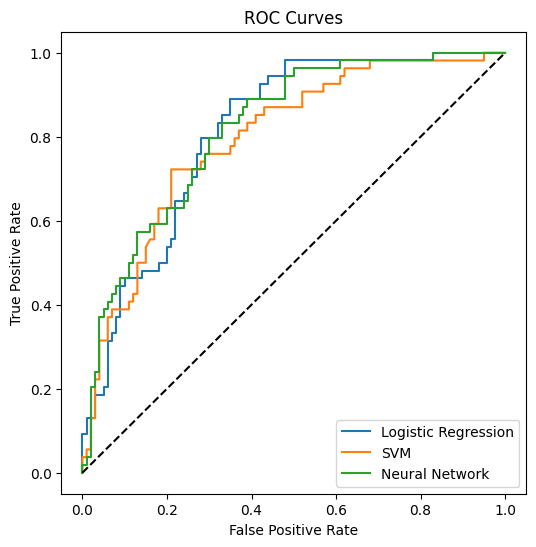

In [7]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve

plt.figure(figsize=(6,6))
for name, model in models.items():
    proba = model.predict_proba(X_test_s)[:,1]
    fpr, tpr, _ = roc_curve(y_test, proba)
    plt.plot(fpr, tpr, label=name)
plt.plot([0,1],[0,1],'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves')
plt.legend()
plt.show()

Step 8 — Find the key risk factors

In [8]:
coefs = pd.Series(log.coef_[0], index=X.columns).sort_values(key=abs, ascending=False)
print(coefs)

Glucose                     1.182511
BMI                         0.688735
Pregnancies                 0.377502
DiabetesPedigreeFunction    0.233386
Age                         0.147798
Insulin                    -0.066157
BloodPressure              -0.044066
SkinThickness               0.028225
dtype: float64
